# Runing before

In [2]:
%load_ext autoreload
%autoreload 2
import sys
sys.path.append("../lib")


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# File Structure

In [ ]:
import numpy as np
from astropy.io import fits

from compute_lensing_for_mock_catalog import Simulated_Lensing_with_multipole

def fits_row_to_obj_new(row, nnn=256):
    """
    Convert one FITS row (astropy.io.fits.fitsrec.FITS_record)
    to the obj dict required by __init__.

    Includes columns added after merging JSON:
    images, image_sep, apparent_mag_first_arrival_i_band, image_number.
    """
    obj = {
        "zlens": row["lens_redshift"],
        "zsource": row["source_redshift"],
        "v_disp": row["v_disp"],
        "q": row["q_SIE"],
        "lambda_q": row["lambda_q"],
        "a3_over_a_signed": row["a3_over_a_signed"],
        "delta_phi_m3": row["delta_phi_m3"],
        "a4_over_a_signed": row["a4_over_a_signed"],
        "delta_phi_m4": row["delta_phi_m4"],
        "gamma_external": row["amp_shear"],
        "phi_external": row["pa_shear"],
        "source_xlocation": row["source_xlocation"],
        "source_ylocation": row["source_ylocation"],
        "absolute_mag_i_band_ab": row["absolute_mag_i_band_ab"],
        "log_joint": row["log_joint"],
        "nnn": nnn,
        "gamma_slope": 2,
        "center_x": 0,
        "center_y": 0,
        "images": row["images"].decode("ascii").strip()
        if isinstance(row["images"], (bytes, bytearray))
        else str(row["images"]),
        "image_sep": row["image_sep"],
        "apparent_mag_first_arrival_i_band": row["apparent_mag_first_arrival_i_band"],
        "image_number": row["image_number"],
    }
    return obj


def load_quad_sim_by_idx(
    fits_path="Theory_Mock/lensed_qso_mock_multipole.fits",
    idx=None,
    nnn=1000,
):
    """
    Load one system by idx from a merged FITS file.

    Returns obj, sim, idx.
    """
    import numpy as np
    from astropy.io import fits

    if idx is None:
        raise ValueError("idx must be provided.")

    with fits.open(fits_path) as hdul:
        data = hdul[1].data
        if not (0 <= idx < len(data)):
            raise IndexError(f"idx {idx} out of range (0 ~ {len(data)-1})")

        row = data[idx]
        obj = fits_row_to_obj_new(row, nnn=nnn)
        sim = Simulated_Lensing_with_multipole(obj)

    return obj, sim, idx

path = "Data/lensed_qso_mock_multipole.fits"
with fits.open(path) as hdul:
    nrows = len(hdul[1].data)

random_idx = np.random.randint(0, nrows)

obj, sim, picked_idx = load_quad_sim_by_idx(
    fits_path=path,
    idx=random_idx,
    nnn=1000,
)

print(f"Randomly selected row index: {picked_idx}")


Randomly selected row index: 876


In [13]:
print(sim.obj)

{'zlens': 1.127078497480986, 'zsource': 5.212474623791617, 'v_disp': 190.26982295612078, 'q': 0.7905116021242915, 'lambda_q': 1.237, 'a3_over_a_signed': 0.0028679002156275783, 'delta_phi_m3': 0.07027676320222076, 'a4_over_a_signed': 0.002683288427155174, 'delta_phi_m4': 0.21710579804845284, 'gamma_external': 0.03267869746305514, 'phi_external': 301.11749661515506, 'source_xlocation': -0.2906647744387101, 'source_ylocation': 0.3781203748444568, 'absolute_mag_i_band_ab': -16.509144457208045, 'log_joint': 9.718836147068302, 'nnn': 1000, 'gamma_slope': 2, 'center_x': 0, 'center_y': 0, 'images': '[{"position": [-0.8712311387062073, 0.8371535539627075], "kappa": 0.2815675139427185, "gamma1": -0.004584181122481823, "gamma2": 0.2540191411972046, "magnification": 2.2144267559051514, "timedelay": -110.41246795654297, "apparent_mag_i_band": 31.12504180424472}, {"position": [0.0012018167180940509, -0.0018626537639647722], "kappa": 174.8454132080078, "gamma1": -17.565837860107422, "gamma2": 28.5105

In [14]:
sim_rest = sim.cal_each_image()
print(sim_rest)

{'images': [{'position': [-0.8712311387062073, 0.8371535539627075], 'kappa': 0.2815675139427185, 'gamma1': -0.004584181122481823, 'gamma2': 0.2540191411972046, 'magnification': 2.2144267559051514, 'timedelay': -110.41246795654297, 'apparent_mag_i_band': 31.12504180424472}, {'position': [0.0012018167180940509, -0.0018626537639647722], 'kappa': 174.8454132080078, 'gamma1': -17.565837860107422, 'gamma2': 28.510560989379883, 'magnification': 4.826605072594248e-05, 'timedelay': 23.33672332763672, 'apparent_mag_i_band': 42.779090692254044}, {'position': [0.11148630082607269, -0.18593990802764893], 'kappa': 1.6869617700576782, 'gamma1': -0.8099534511566162, 'gamma2': 1.4592955112457275, 'magnification': -0.43218475580215454, 'timedelay': 16.832834243774414, 'apparent_mag_i_band': 32.89902149420833}], 'image_sep': 1.418609811727063, 'apparent_mag_first_arrival_i_band': 31.12504180424472, 'image_number': 3}


In [15]:
alpha1_SIE,alpha2_SIE = sim.Get_mainhalo_Mock_SIE()

In [16]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
from matplotlib import colors
from Lensing_tool import alphas_to_mu


def plot_crit_caustics_from_alphas(
    models,
    xi1, xi2,
    dsx_arc,
    cut_c_p=1.0,
    figsize=(20, 10),
    title_left="Critical Curves (Image Plane)",
    title_right="Caustics (Source Plane)",
    image_points=None,
    source_points=None,
    sim_results=None,
    img_style=None,
    src_style=None,
    backproject_if_no_source=True,
    show=True,
):
    """
    Plot critical curves and caustics, with optional image/source points.

    Returns image and source scatter handles in the results dict.
    """
    tab10 = plt.get_cmap('tab10').colors
    default_linestyles_crit = [':', '--', '-.', '-']
    default_linestyles_caus = ['-', '--', ':', '-.']

    def _ensure_style(style_dict, fallback_color, fallback_ls, fallback_lw=2.0):
        style = {} if style_dict is None else dict(style_dict)
        style.setdefault('color', fallback_color)
        style.setdefault('linestyle', fallback_ls)
        style.setdefault('linewidth', fallback_lw)
        return style

    def _to_contour_kwargs(style):
        return {
            'colors': style.get('color', 'k'),
            'linestyles': style.get('linestyle', '-'),
            'linewidths': style.get('linewidth', 2.0),
        }

    if img_style is None:
        img_style = {'marker': 'o', 's': 70, 'edgecolor': 'k', 'facecolor': 'none', 'linewidths': 1.5, 'zorder': 6}
    if src_style is None:
        src_style = {'marker': 'x', 's': 90, 'color': 'k', 'linewidths': 2.0, 'zorder': 6}

    def enclosed_areas(contour):
        areas = []
        if contour is None:
            return areas
        if len(contour.allsegs) > 0 and len(contour.allsegs[0]) > 0:
            for seg in contour.allsegs[0]:
                x, y = seg[:, 0], seg[:, 1]
                area = 0.5 * np.abs(np.dot(x, np.roll(y, 1)) - np.dot(y, np.roll(x, 1)))
                areas.append(area)
        return areas

    def _extract_images_from_sim(sim_res):
        try:
            return [tuple(p['position']) for p in sim_res.get('images', [])]
        except Exception:
            return None

    def bilinear_interp(xi1_grid, xi2_grid, field, xq, yq):
        xs = xi2_grid[0, :]
        ys = xi1_grid[:, 0]
        x_min, x_max = xs[0], xs[-1]
        y_min, y_max = ys[0], ys[-1]
        xq = np.asarray(xq)
        yq = np.asarray(yq)
        xq_cl = np.clip(xq, x_min, x_max)
        yq_cl = np.clip(yq, y_min, y_max)

        ix1 = np.searchsorted(xs, xq_cl) - 1
        iy1 = np.searchsorted(ys, yq_cl) - 1
        ix1 = np.clip(ix1, 0, xs.size - 2)
        iy1 = np.clip(iy1, 0, ys.size - 2)

        x1 = xs[ix1]; x2 = xs[ix1 + 1]
        y1 = ys[iy1]; y2 = ys[iy1 + 1]
        wx = (xq_cl - x1) / (x2 - x1 + 1e-30)
        wy = (yq_cl - y1) / (y2 - y1 + 1e-30)

        f11 = field[iy1, ix1]
        f21 = field[iy1, ix1 + 1]
        f12 = field[iy1 + 1, ix1]
        f22 = field[iy1 + 1, ix1 + 1]

        fxy = (1 - wx) * (1 - wy) * f11 + wx * (1 - wy) * f21 + (1 - wx) * wy * f12 + wx * wy * f22
        return fxy

    if (image_points is None) and (sim_results is not None):
        image_points = _extract_images_from_sim(sim_results)

    fig, axes = plt.subplots(1, 2, figsize=figsize)
    ax0, ax1 = axes

    cutd_x = 0.5 * (np.nanmax(xi2) - np.nanmin(xi2))
    cutd_y = 0.5 * (np.nanmax(xi1) - np.nanmin(xi1))
    cutd = min(cutd_x, cutd_y)

    legend_handles = []
    results = {}
    image_scatter_handles = []
    source_scatter_handles = []

    for i, m in enumerate(models):
        name = m.get('name', f'Model {i+1}')
        alpha_x_map = m['alpha_x']
        alpha_y_map = m['alpha_y']

        ax_map, ay_map = alpha_y_map, alpha_x_map

        yi1, yi2, mu, kappa, g1, g2 = alphas_to_mu(ax_map, ay_map, dsx_arc, xi1, xi2)
        gamma = np.sqrt(g1**2 + g2**2)
        lambdat = 1 - kappa - gamma

        color = tab10[i % len(tab10)]
        crit_style = _ensure_style(m.get('crit_style'), color, default_linestyles_crit[i % len(default_linestyles_crit)])
        caus_style = _ensure_style(m.get('caus_style'), color, default_linestyles_caus[i % len(default_linestyles_caus)])
        crit_kw = _to_contour_kwargs(crit_style)
        caus_kw = _to_contour_kwargs(caus_style)

        c_img = ax0.contour(xi2, xi1, lambdat, levels=[0.0], **crit_kw)
        c_src = ax1.contour(yi2, yi1, lambdat, levels=[0.0], **caus_kw)

        areas = enclosed_areas(c_src)
        if areas:
            amax = float(np.max(areas))
            reff = float(np.sqrt(amax / np.pi))
            print(f"{name} caustic effective radius: {reff:.4f} arcsec")
        else:
            reff = None
            print(f"{name} no closed caustic contour found")

        legend_handles.append(
            mlines.Line2D([], [], color=crit_style['color'],
                          linestyle=crit_style['linestyle'],
                          linewidth=crit_style['linewidth'],
                          label=f"Critical ({name})")
        )
        legend_handles.append(
            mlines.Line2D([], [], color=caus_style['color'],
                          linestyle=caus_style['linestyle'],
                          linewidth=caus_style['linewidth'],
                          label=f"Caustic ({name})")
        )

        results[name] = {
            'areas': areas,
            'r_eff': reff,
            'contour_img': c_img,
            'contour_src': c_src,
            'yi1': yi1, 'yi2': yi2,
            'lambdat': lambdat,
        }

    if image_points is not None and len(image_points) > 0:
        P = np.asarray(image_points, dtype=float)
        img_sc = ax0.scatter(P[:, 1], P[:, 0],
                             marker=img_style.get('marker', 'o'),
                             s=img_style.get('s', 70),
                             edgecolors=img_style.get('edgecolor', 'k'),
                             facecolors=img_style.get('facecolor', 'none'),
                             linewidths=img_style.get('linewidths', 1.5),
                             zorder=img_style.get('zorder', 6),
                             label='Image points')
        image_scatter_handles.append(img_sc)

    plotted_sources = False
    if source_points is not None and len(source_points) > 0:
        S = np.asarray(source_points, dtype=float)
        src_sc = ax1.scatter(S[:, 1], S[:, 0],
                             marker=src_style.get('marker', 'x'),
                             s=src_style.get('s', 90),
                             c=src_style.get('color', 'k'),
                             linewidths=src_style.get('linewidths', 2.0),
                             zorder=src_style.get('zorder', 6),
                             label='Source points')
        source_scatter_handles.append(src_sc)
        plotted_sources = True
    elif backproject_if_no_source and (image_points is not None) and len(models) > 0:
        first_model = models[0]
        alpha_x_map = first_model['alpha_x']
        alpha_y_map = first_model['alpha_y']
        P = np.asarray(image_points, dtype=float)
        ax_interp = bilinear_interp(xi1, xi2, alpha_x_map, P[:, 0], P[:, 1])
        ay_interp = bilinear_interp(xi1, xi2, alpha_y_map, P[:, 0], P[:, 1])
        Y_est = np.column_stack([P[:, 0] - ax_interp, P[:, 1] - ay_interp])

        src_sc1 = ax1.scatter(Y_est[:, 0], Y_est[:, 1],
                              marker='^', s=70, edgecolors='k', facecolors='w',
                              linewidths=1.2, zorder=6, label='Back-projected (per image)')
        source_scatter_handles.append(src_sc1)

        y_mean = Y_est.mean(axis=0)
        src_sc2 = ax1.scatter([y_mean[0]], [y_mean[1]],
                              marker='*', s=160, c='gold', edgecolors='k',
                              linewidths=1.0, zorder=7, label='Estimated source (mean)')
        source_scatter_handles.append(src_sc2)
        results['estimated_source'] = {'per_image': Y_est, 'mean': y_mean}
        plotted_sources = True

    ax0.set_aspect('equal')
    ax0.set_xlabel("X (arcsec)")
    ax0.set_ylabel("Y (arcsec)")
    ax0.set_title(title_left)
    ax0.set_xlim(-cutd, cutd)
    ax0.set_ylim(-cutd, cutd)

    ax1.set_aspect('equal')
    ax1.set_xlabel("X (arcsec)")
    ax1.set_title(title_right)
    ax1.set_xlim(-cutd * cut_c_p, cutd * cut_c_p)
    ax1.set_ylim(-cutd * cut_c_p, cutd * cut_c_p)

    extra_handles = []
    if image_scatter_handles:
        extra_handles.append(mlines.Line2D([], [], marker=img_style.get('marker', 'o'),
                                           color='k', linestyle='None',
                                           markersize=np.sqrt(img_style.get('s', 70))/2.5,
                                           markerfacecolor=img_style.get('facecolor', 'none'),
                                           markeredgecolor=img_style.get('edgecolor', 'k'),
                                           label='Image points'))
    if plotted_sources:
        extra_handles.append(mlines.Line2D([], [], marker=src_style.get('marker', 'x'),
                                           color=src_style.get('color', 'k'), linestyle='None',
                                           markersize=np.sqrt(src_style.get('s', 90))/2.5,
                                           label='Source points / estimates'))

    fig.legend(handles=[*legend_handles, *extra_handles],
               loc='upper center', bbox_to_anchor=(0.5, 0.03),
               ncol=3, fontsize=12, frameon=False)

    plt.tight_layout(rect=[0, 0.06, 1, 1])

    if show:
        plt.show()

    results['image_scatter'] = image_scatter_handles
    results['source_scatter'] = source_scatter_handles

    return fig, (ax0, ax1), results


SIE caustic effective radius: 0.0839 arcsec
Mul caustic effective radius: 0.0841 arcsec


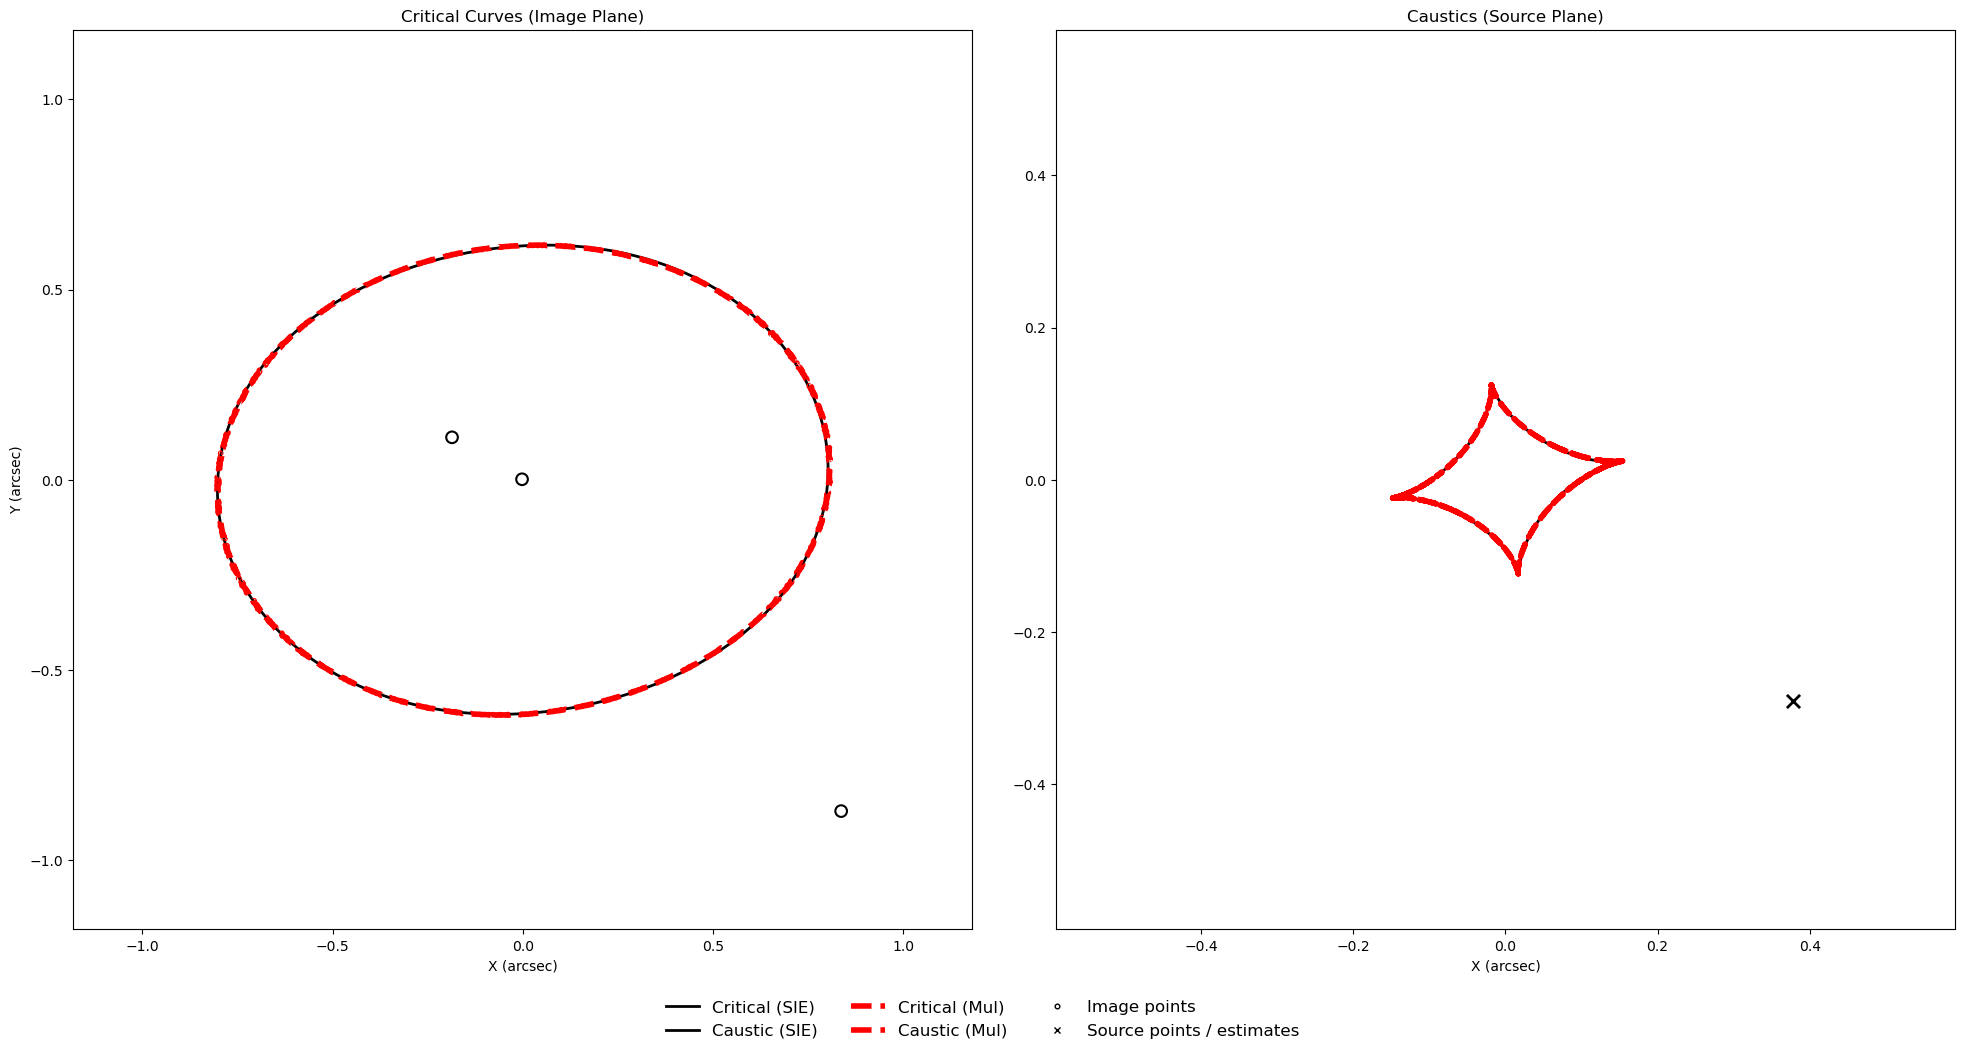

SIE max effective radius = 0.08394114390581094
Mul max effective radius = 0.08407604362652281


In [17]:
models = [
    {
        'name': 'SIE',
        'alpha_x': alpha2_SIE,
        'alpha_y': alpha1_SIE,
        'crit_style': {'color': 'k', 'linestyle': '-',  'linewidth': 2.0},
        'caus_style': {'color': 'k', 'linestyle': '-',  'linewidth': 2.0},
    },
    {
        'name': 'Mul',
        'alpha_x': sim.alpha2_global,
        'alpha_y': sim.alpha1_global,
        'crit_style': {'color': 'r', 'linestyle': '--', 'linewidth': 4.0},
        'caus_style': {'color': 'r', 'linestyle': '--', 'linewidth': 4.0},
    }
]

sim_rest = sim.cal_each_image()

fig, axes, results = plot_crit_caustics_from_alphas(
    models=models,
    xi1=sim.xi1, xi2=sim.xi2,
    dsx_arc=sim.dsx_arc,
    cut_c_p=0.5,
    sim_results=sim_rest,
    source_points=[
        (sim.obj['source_xlocation'], sim.obj['source_ylocation'])
    ]
)

for name, res in results.items():
    if isinstance(res, dict) and 'r_eff' in res:
        print(f"{name} max effective radius = {res['r_eff']}")


# Test Cusp Selection

In [3]:
from astropy.io import fits

def filter_image_number_4(file_path):
    with fits.open(file_path) as hdul:
        data = hdul[1].data
        filtered = data[data['image_number'] == 5]
    
    return filtered

file_path = "../Data/lensed_qso_mock.fits"
# Run
filtered_data = filter_image_number_4(file_path)
print(f"Total {len(filtered_data)} systems with image_number = 4")
# print("First 5 rows example：\n", filtered_data[:1])

Total 23746 systems with image_number = 4


In [13]:
from Rcusp_tool import select_cusp_systems_with_progress
cusp_data = select_cusp_systems_with_progress(file_path)

Filtering cusp configurations: 100%|██████████| 23746/23746 [00:03<00:00, 6314.35it/s]

Selected 2367 cusp configuration systems


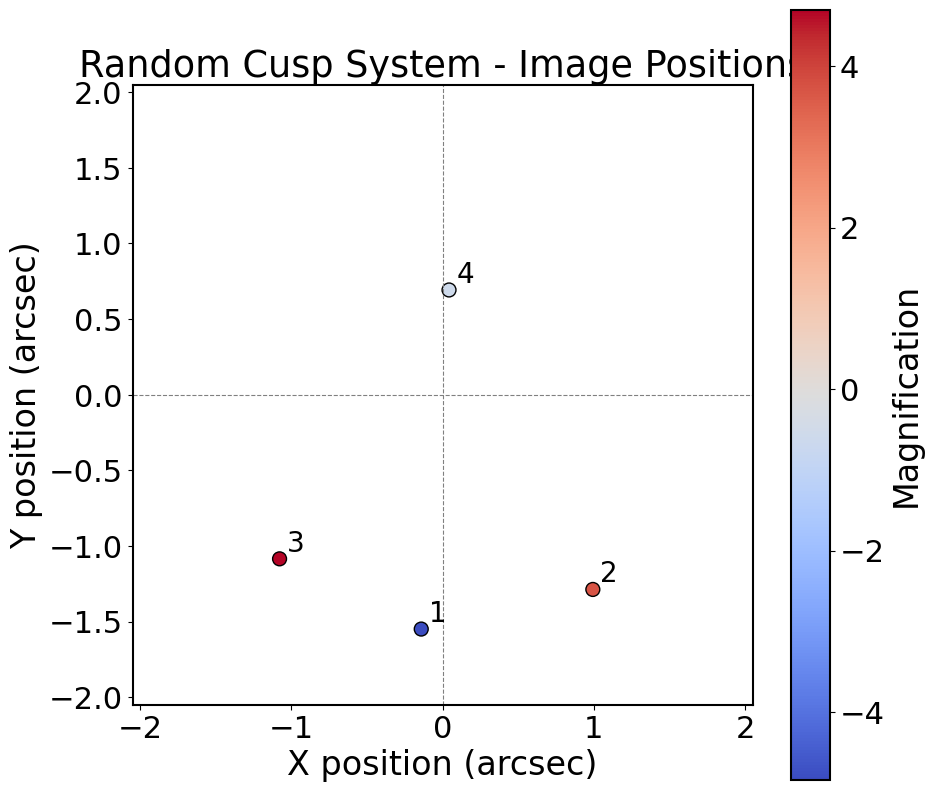

In [15]:
import numpy as np
import matplotlib.pyplot as plt
import random


def plot_random_cusp_system(cusp_data, margin=0.5):
    # Randomly choose a cusp system
    sample = random.choice(cusp_data)
    row = sample["data"]

    xs = row['image_xlocation']
    ys = row['image_ylocation']
    mags = row['magnification']

    plt.figure(figsize=(10, 10))
    sc = plt.scatter(xs, ys, c=mags, cmap='coolwarm', s=100, edgecolor='black')
    
    for i, (x, y) in enumerate(zip(xs, ys)):
        plt.text(x + 0.05, y + 0.05, f"{i+1}", fontsize=20)

    # Compute bounds so (0,0) stays centered
    x_min, x_max = np.min(xs), np.max(xs)
    y_min, y_max = np.min(ys), np.max(ys)
    max_range = max(abs(x_min), abs(x_max), abs(y_min), abs(y_max)) + margin

    plt.xlim(-max_range, max_range)
    plt.ylim(-max_range, max_range)

    plt.axhline(0, color='gray', linestyle='--', linewidth=0.8)
    plt.axvline(0, color='gray', linestyle='--', linewidth=0.8)
    plt.colorbar(sc, label="Magnification")
    plt.xlabel("X position (arcsec)")
    plt.ylabel("Y position (arcsec)")
    plt.title("Random Cusp System - Image Positions")
    plt.gca().set_aspect('equal')
    plt.grid(False)
    plt.show()

# Run
plot_random_cusp_system(cusp_data)

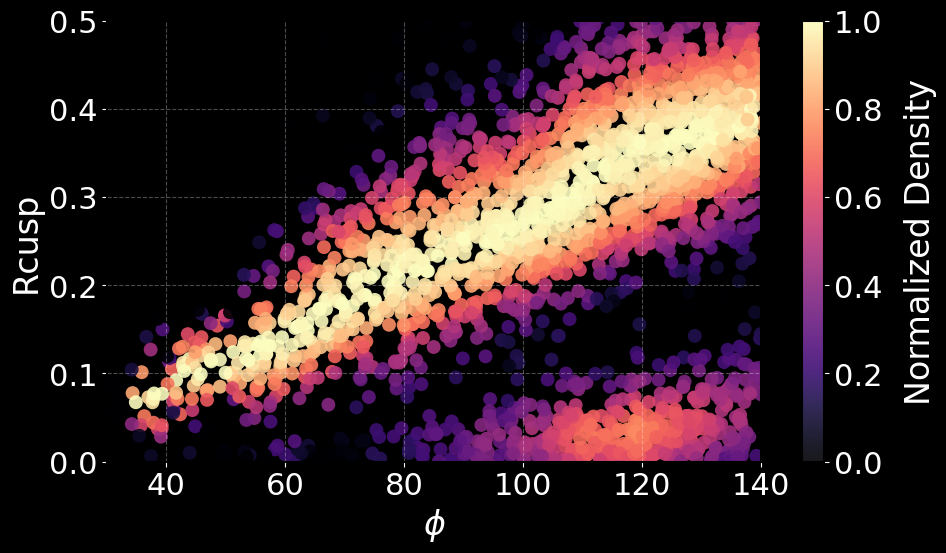

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde
import matplotlib.colors as mcolors
from scipy.interpolate import UnivariateSpline

def plot_rcusp_vs_phi_scatter_kde(cusp_data):
    phi_vals = np.array([entry["phi"] for entry in cusp_data])
    rcusp_vals = np.array([entry["R_cusp"] for entry in cusp_data])

    phi_min, phi_max = 30, 140
    rcusp_min, rcusp_max = 0.0, 0.5
    bin_width = 2.0
    phi_bins = np.arange(phi_min, phi_max + bin_width, bin_width)

    plt.figure(figsize=(10, 6), facecolor='black')
    # plt.figure(figsize=(10, 6))
    ax = plt.gca()
    ax.set_facecolor('black')

    # KDE density estimation
    values = np.vstack([phi_vals, rcusp_vals])
    kde = gaussian_kde(values)
    density = kde(values)

    # Bin-wise local normalization
    norm_density = np.zeros_like(density)
    bin_centers, perc_30, perc_70 = [], [], []

    for j in range(len(phi_bins) - 1):
        mask = (phi_vals >= phi_bins[j]) & (phi_vals < phi_bins[j + 1])
        if np.sum(mask) < 5:
            continue
        d = density[mask]
        norm_density[mask] = (d - d.min()) / (d.ptp() + 1e-8)

        Rcusp_bin = rcusp_vals[mask]
        bin_center = 0.5 * (phi_bins[j] + phi_bins[j + 1])
        bin_centers.append(bin_center)
        perc_30.append(np.percentile(Rcusp_bin, 30))
        perc_70.append(np.percentile(Rcusp_bin, 70))

    # Scatter plot colored by local density
    sc = ax.scatter(
        phi_vals, rcusp_vals,
        c=norm_density,
        cmap='magma',
        s=100,
        edgecolor='none',
        alpha=0.9,
        norm=mcolors.Normalize(vmin=0, vmax=1)
    )

    cbar = plt.colorbar(sc, ax=ax)
    cbar.set_label("Normalized Density", color='white', labelpad=15)

    cbar.ax.yaxis.set_tick_params(color="white")         # White tick marks
    plt.setp(cbar.ax.get_yticklabels(), color="white")   # White tick labels

    ax.set_xlim(phi_min, phi_max)
    ax.set_ylim(rcusp_min, rcusp_max)
    ax.set_xlabel(r"$\phi$", color='white')
    ax.set_ylabel("Rcusp", color='white')

    ax.grid(True, linestyle='--', alpha=0.3, color='white')
    ax.tick_params(colors='white')

    plt.tight_layout()
    plt.show()

# Run
plot_rcusp_vs_phi_scatter_kde(cusp_data)